<a href="https://colab.research.google.com/github/oabuhamed/metabolic-syndrome-neural-network-RISK-PREDICTION/blob/main/metabolic_syndrome_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Metabolic Syndrome Prediction project


In [75]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
pd.set_option('display.max_columns', 100)

In [76]:
#load the data
import pandas as pd
df = pd.read_csv('https://query.data.world/s/wiz6fht7uok2yy3odtbcsb4rvs6hib?dws=00000')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   seqn               2401 non-null   int64  
 1   Age                2401 non-null   int64  
 2   Sex                2401 non-null   object 
 3   Marital            2193 non-null   object 
 4   Income             2284 non-null   float64
 5   Race               2401 non-null   object 
 6   WaistCirc          2316 non-null   float64
 7   BMI                2375 non-null   float64
 8   Albuminuria        2401 non-null   int64  
 9   UrAlbCr            2401 non-null   float64
 10  UricAcid           2401 non-null   float64
 11  BloodGlucose       2401 non-null   int64  
 12  HDL                2401 non-null   int64  
 13  Triglycerides      2401 non-null   int64  
 14  MetabolicSyndrome  2401 non-null   object 
dtypes: float64(5), int64(6), object(4)
memory usage: 281.5+ KB


,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,No MetSyn
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,No MetSyn
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,No MetSyn
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,No MetSyn
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,No MetSyn


In [77]:
#inspection of the data
df.shape

(2401, 15)

In [78]:
# Perform some basic data exploration
print('\nFeature DataTypes:')
print(df.dtypes)
print('\n')

print('\nNumber of Missing Values per Feature:')
print(df.isnull().sum())
print('\n')

df.describe()


Feature DataTypes:
seqn                   int64
Age                    int64
Sex                   object
Marital               object
Income               float64
Race                  object
WaistCirc            float64
BMI                  float64
Albuminuria            int64
UrAlbCr              float64
UricAcid             float64
BloodGlucose           int64
HDL                    int64
Triglycerides          int64
MetabolicSyndrome     object
dtype: object



Number of Missing Values per Feature:
seqn                   0
Age                    0
Sex                    0
Marital              208
Income               117
Race                   0
WaistCirc             85
BMI                   26
Albuminuria            0
UrAlbCr                0
UricAcid               0
BloodGlucose           0
HDL                    0
Triglycerides          0
MetabolicSyndrome      0
dtype: int64




,seqn,Age,Income,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides
count,2401.000000,2401.000000,2284.000000,2316.000000,2375.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000
mean,67030.674302,48.691795,4005.253940,98.307254,28.702189,0.154102,43.626131,5.489046,108.247813,53.369429,128.125364
std,2823.565114,17.632852,2954.032186,16.252634,6.662242,0.422780,258.272829,1.439358,34.820657,15.185537,95.322477
min,62161.000000,20.000000,300.000000,56.200000,13.400000,0.000000,1.400000,1.800000,39.000000,14.000000,26.000000
25%,64591.000000,34.000000,1600.000000,86.675000,24.000000,0.000000,4.450000,4.500000,92.000000,43.000000,75.000000
50%,67059.000000,48.000000,2500.000000,97.000000,27.700000,0.000000,7.070000,5.400000,99.000000,51.000000,103.000000
75%,69495.000000,63.000000,6200.000000,107.625000,32.100000,0.000000,13.690000,6.400000,110.000000,62.000000,150.000000
max,71915.000000,80.000000,9000.000000,176.000000,68.700000,2.000000,5928.000000,11.300000,382.000000,156.000000,1562.000000


In [79]:
#drop the ID coumn
df = df.drop(columns='seqn')

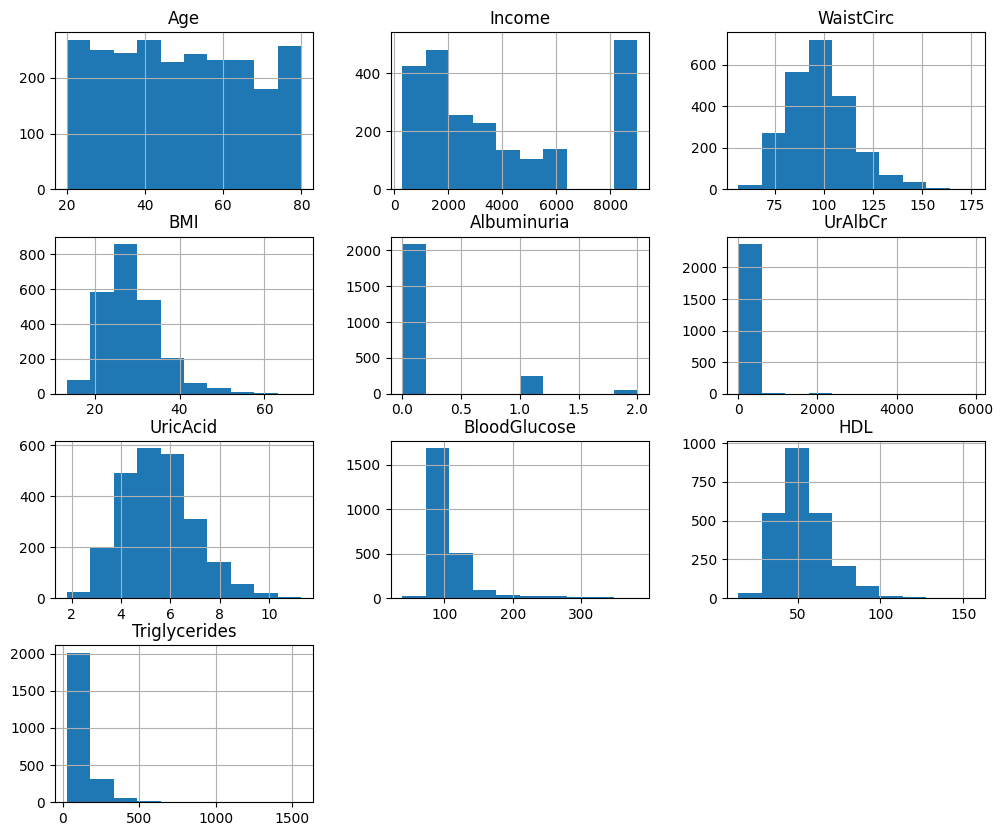

In [80]:
df.hist(figsize=(12,10))
plt.show()

In [81]:
#convert object features to integers
df['Sex'].value_counts()

,count
Sex,
Female,1211
Male,1190


In [82]:
sex_dict = {"Male": 1,"Female": 0}
df['Sex'] = df['Sex'].replace(sex_dict)
df['Sex'].value_counts()

/tmp/ipykernel_760/1918010042.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace(sex_dict)


,count
Sex,
0,1211
1,1190


In [83]:
df['Marital'].value_counts()

,count
Marital,
Married,1192
Single,498
Divorced,242
Widowed,166
Separated,95


In [84]:
marital_dict = {'Married':0,'Single':1,'Divorced':2,'Widowed':3,'Separated':4}
df['Marital'] = df['Marital'].replace(marital_dict)
df['Marital'].value_counts()

/tmp/ipykernel_760/1395113322.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Marital'] = df['Marital'].replace(marital_dict)


,count
Marital,
0.0,1192
1.0,498
2.0,242
3.0,166
4.0,95


In [85]:
df['Race'].value_counts()

,count
Race,
White,933
Black,548
Asian,349
Hispanic,257
MexAmerican,253
Other,61


In [86]:
race_dict = {'White':0,'Black':1,'Asian':2,'Hispanic':3,'MexAmerican':4,'Other':5}
df['Race']=df['Race'].replace(race_dict)
df['Race'].value_counts()

/tmp/ipykernel_760/4195219604.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Race']=df['Race'].replace(race_dict)


,count
Race,
0,933
1,548
2,349
3,257
4,253
5,61


In [87]:
df['MetabolicSyndrome'].value_counts()

,count
MetabolicSyndrome,
No MetSyn,1579
MetSyn,822


In [88]:
metabolicSyndrome_dict = {'No MetSyn':0, 'MetSyn':1}
df['MetabolicSyndrome']= df['MetabolicSyndrome'].replace(metabolicSyndrome_dict)
df['MetabolicSyndrome'].value_counts()

/tmp/ipykernel_760/3813550984.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MetabolicSyndrome']= df['MetabolicSyndrome'].replace(metabolicSyndrome_dict)


,count
MetabolicSyndrome,
0,1579
1,822


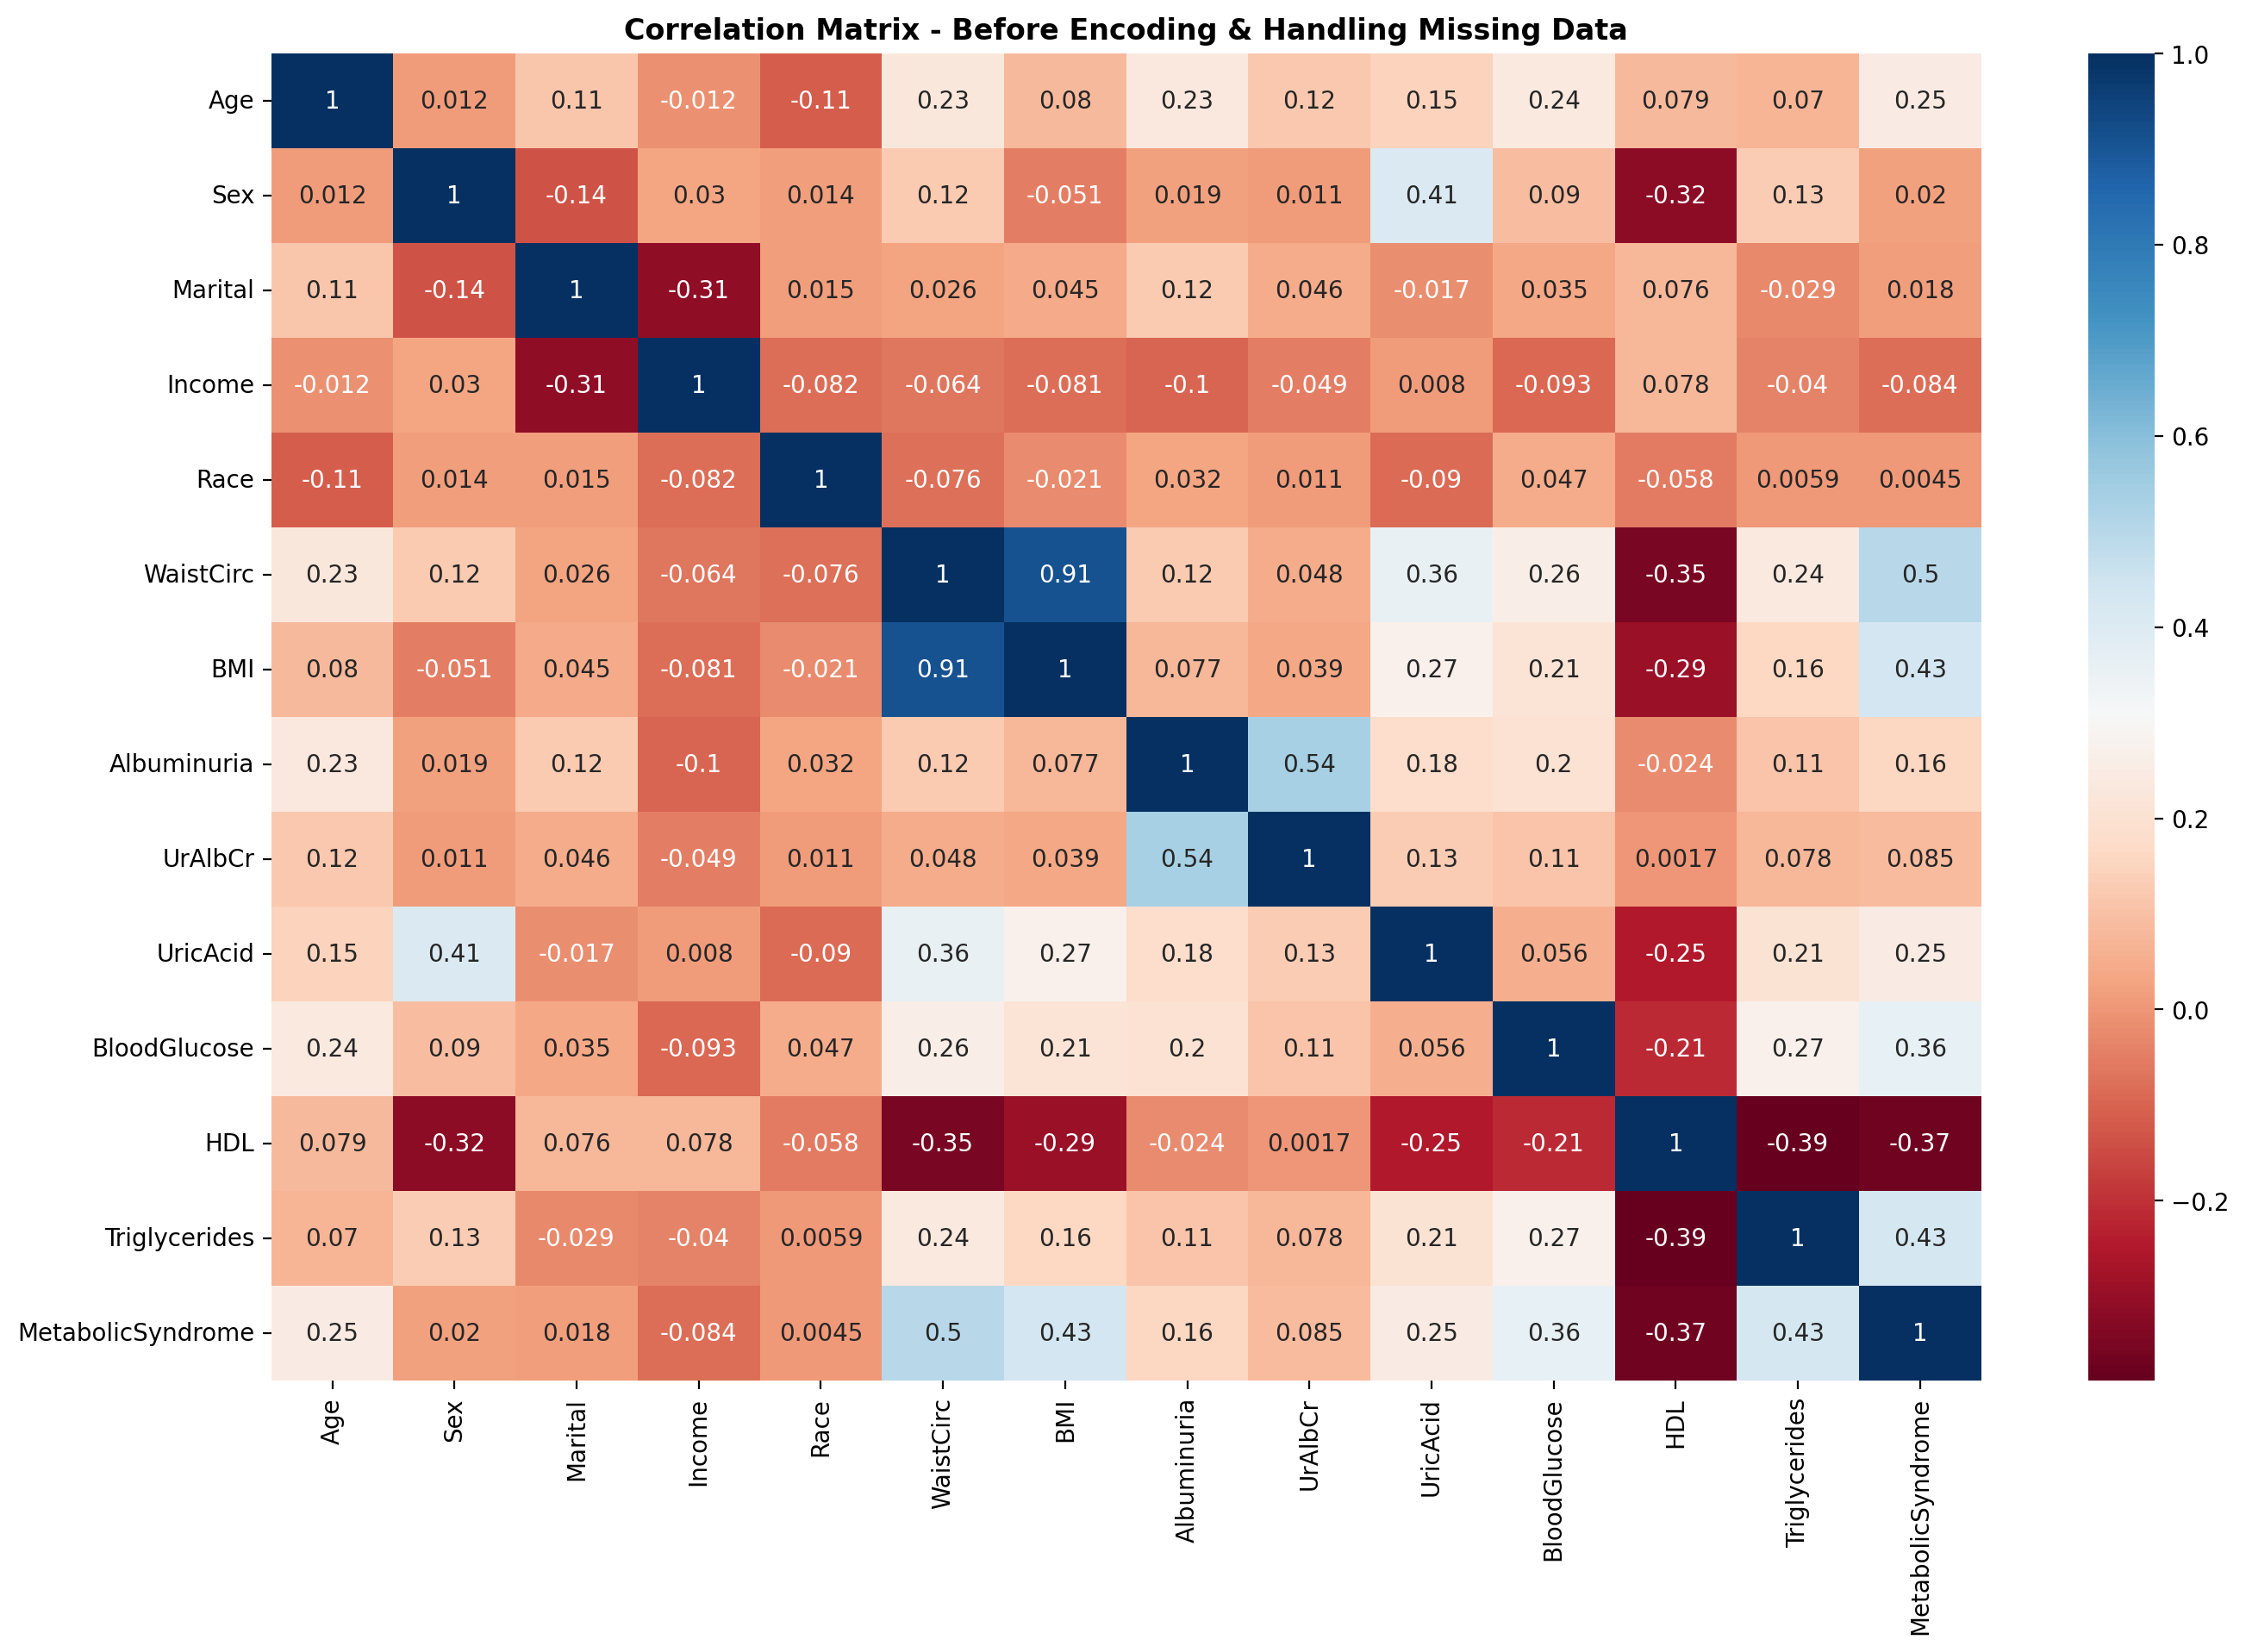

In [89]:
plt.figure(figsize = (16,10), dpi=200)
ax = plt.axes()
sns.heatmap(df.corr(), annot = True, cmap='RdBu', ax=ax)
ax.set_title('Correlation Matrix - Before Encoding & Handling Missing Data', weight='bold')
plt.show()


The correlation heatmap shows the relationship between each feature and metabolic syndrome.
Waist circumference (0.50)
triglycerides (0.43)
BMI (0.43)
all show the strongest positive correlations with metabolic syndrome, indicating that higher values are associated with a higher prbapilty of the condition.
Blood glucose also shows a moderate positive relationship (0.36).
 HDL cholesterol shows a negative correlation (-0.37), meaning higher HDL levels are associated with lower risk.
 These findings align with the known clinical components of metabolic syndrome.

##Preprocessing the data

In [90]:
#impute the missing valuse

- most frequent for Maretial Status

In [91]:
marital_imputer = SimpleImputer(strategy="most_frequent")

df[["Marital"]] = marital_imputer.fit_transform(df[["Marital"]])

In [92]:
df['Marital'].isna().sum()

np.int64(0)

-Median for BMI , WaistCirc,Inocome

In [93]:
imputer = SimpleImputer(strategy="median")

df[["BMI","WaistCirc","Income"]] = imputer.fit_transform(df[["BMI","WaistCirc","Income"]])


In [94]:
df[["BMI","WaistCirc","Income"]].isnull().sum()

,0
BMI,0
WaistCirc,0
Income,0


In [95]:
df.isna().sum()

,0
Age,0
Sex,0
Marital,0
Income,0
Race,0
WaistCirc,0
BMI,0
Albuminuria,0
UrAlbCr,0
UricAcid,0


-Define the target and making the train and test split


In [96]:
X = df.drop("MetabolicSyndrome", axis=1)
y = df["MetabolicSyndrome"]

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

-Train with random forest


In [98]:
#fit the random forest model
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [99]:
#make predictions
y_pred = rf.predict(X_test)

In [100]:
#evaluate the model
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8818635607321131


In [101]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       397
           1       0.86      0.78      0.82       204

    accuracy                           0.88       601
   macro avg       0.88      0.86      0.87       601
weighted avg       0.88      0.88      0.88       601



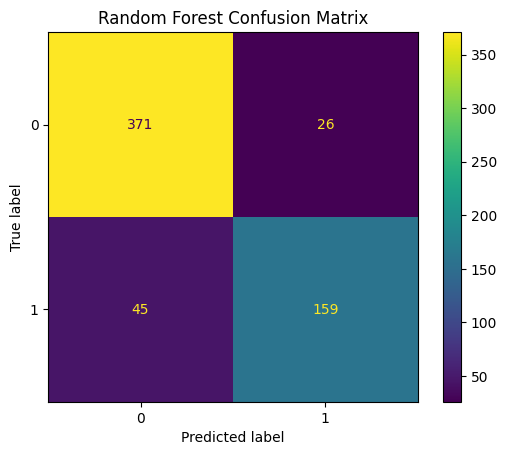

In [102]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.title("Random Forest Confusion Matrix")

plt.show()

-Permutation Imoprtance top 10 features

In [103]:
#calculate permutation importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(rf,X_test,y_test,n_repeats=10,random_state=42)

In [104]:
## make the mean importances into a series
permutation_importances = pd.Series(perm_importance['importances_mean'],index=X_test.columns,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

,permutation importance
BloodGlucose,0.090017
Triglycerides,0.064060
WaistCirc,0.034942
HDL,0.020965
BMI,0.018968
Sex,0.014476
Age,0.011481
UrAlbCr,0.004326
Income,0.003161
Marital,0.001664


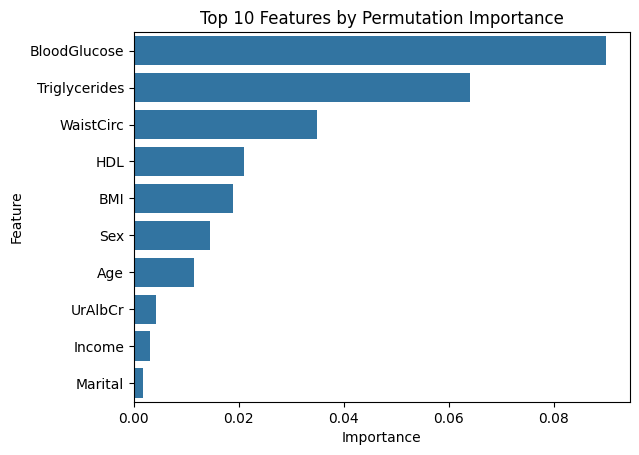

In [105]:
#visualize the top 10 features using permutation importance

top10 = permutation_importances.head(10)

sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Features by Permutation Importance")
plt.xlabel("Importance")
plt.ylabel("Feature");

-visualizing the highest 2 of  the top 10 features

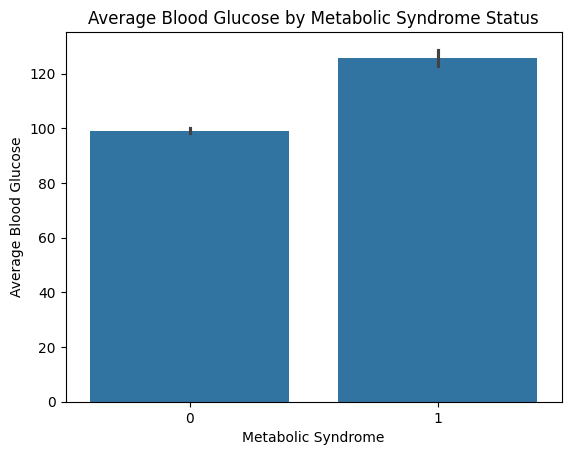

In [106]:
#ploting the Avrage blood glucose
sns.barplot(x="MetabolicSyndrome",y="BloodGlucose",data=df)

plt.title("Average Blood Glucose by Metabolic Syndrome Status")
plt.xlabel("Metabolic Syndrome")
plt.ylabel("Average Blood Glucose");

### Exclusion
Individuals diagnosed with metabolic syndrome have higher average blood glucose levels compared to those without the condition. This pattern is expected because elevated blood glucose is one of the key metabolic abnormalities associated with metabolic syndrome.

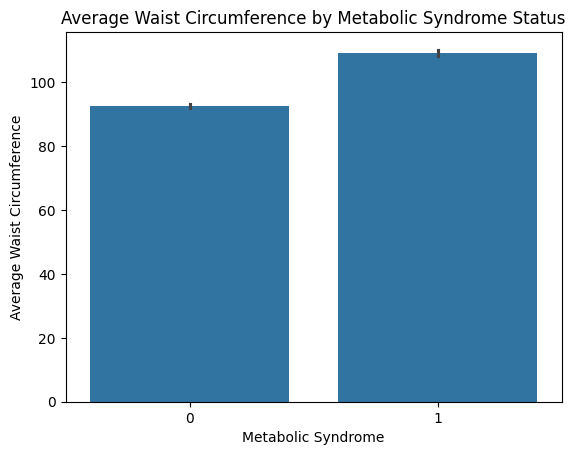

In [107]:
sns.barplot(x="MetabolicSyndrome",y="WaistCirc",data=df)

plt.title("Average Waist Circumference by Metabolic Syndrome Status")
plt.xlabel("Metabolic Syndrome")
plt.ylabel("Average Waist Circumference");

### Exclusion

Patients with metabolic syndrome tend to have a larger waist circumference compared to individuals without the condition. This reflects the strong relationship between central obesity and metabolic syndrome.


#Neural Network Model


## Neural Network Model
This section builds, trains, tunes, and evaluates a neural network for metabolic syndrome prediction.

In [108]:
# Deep learning tools
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn import set_config
set_config(transform_output='pandas')


### Inspect Training Data
Before training the model, inspect the shape and structure of the training features.

In [109]:
X_train.info()
X_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1800 entries, 263 to 860
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            1800 non-null   int64  
 1   Sex            1800 non-null   int64  
 2   Marital        1800 non-null   float64
 3   Income         1800 non-null   float64
 4   Race           1800 non-null   int64  
 5   WaistCirc      1800 non-null   float64
 6   BMI            1800 non-null   float64
 7   Albuminuria    1800 non-null   int64  
 8   UrAlbCr        1800 non-null   float64
 9   UricAcid       1800 non-null   float64
 10  BloodGlucose   1800 non-null   int64  
 11  HDL            1800 non-null   int64  
 12  Triglycerides  1800 non-null   int64  
dtypes: float64(6), int64(7)
memory usage: 196.9 KB


,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides
263,46,0,0.0,8200.0,0,124.0,40.8,0,18.47,3.3,140,53,198
2073,34,1,4.0,3500.0,4,86.2,24.5,0,16.14,6.1,114,83,60
632,33,0,0.0,3500.0,4,75.0,25.0,0,11.54,3.4,97,44,60
1732,49,0,0.0,9000.0,3,95.7,33.3,0,3.81,2.7,89,51,139
765,30,1,0.0,9000.0,2,75.7,21.9,0,7.76,7.1,81,58,394


In [110]:
y_train.info()
y_train.head()

<class 'pandas.core.series.Series'>
Index: 1800 entries, 263 to 860
Series name: MetabolicSyndrome
Non-Null Count  Dtype
--------------  -----
1800 non-null   int64
dtypes: int64(1)
memory usage: 28.1 KB


,MetabolicSyndrome
263,1
2073,0
632,0
1732,0
765,0


In [111]:
#all features are numeric

In [112]:
# Check class balance
y_train.value_counts(normalize = True)

,proportion
MetabolicSyndrome,
0,0.656667
1,0.343333


### Feature Scaling
Neural networks perform better when input features are standardized.

In [113]:
# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
y_train.unique()

array([1, 0])

### Define Input Shape
The input shape corresponds to the number of features in the training data.

In [115]:
# Save the number of input features for use in the neural network architecture
input_shape = X_train_scaled.shape[1]
input_shape

13

### Build Baseline Neural Network
A simple feed-forward neural network is created for binary classification.

In [116]:
# Build a baseline neural network model for binary classification
# The model uses one hidden layer, dropout regularization, and a sigmoid output layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras import metrics

# Build binary classification model within function
def build_model():
    model = Sequential()

    # Input + one hidden layer
    model.add(Input(shape=(input_shape,)))
    model.add(Dense(13, activation='relu'))

    # Dropout layer
    model.add(Dropout(0.2))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=[
            'accuracy',
            metrics.Precision(name='precision'),
            metrics.Recall(name='recall')
        ]
    )

    return model

In [117]:
# Call our build function to build model
clf_model = build_model()

# Get model summary
clf_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 13)             │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196 (784.00 B)

 Trainable params: 196 (784.00 B)

 Non-trainable params: 0 (0.00 B)

### Early Stopping
EarlyStopping is used to stop training when validation performance stops improving.

In [118]:
#adding EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5)

### Train Baseline Neural Network
The model is trained for up to 50 epochs using 20% of the training data for validation.

In [119]:
#training the model
history = clf_model.fit(X_train_scaled, y_train,
                        validation_split=.2,
                        epochs=50,
                        verbose=2, callbacks = [early_stop])

Epoch 1/50
45/45 - 3s - 62ms/step - accuracy: 0.5063 - loss: 0.7497 - precision: 0.3912 - recall: 0.8430 - val_accuracy: 0.6167 - val_loss: 0.6464 - val_precision: 0.4921 - val_recall: 0.9254
Epoch 2/50
45/45 - 0s - 4ms/step - accuracy: 0.6160 - loss: 0.6494 - precision: 0.4596 - recall: 0.8099 - val_accuracy: 0.6944 - val_loss: 0.5813 - val_precision: 0.5583 - val_recall: 0.8582
Epoch 3/50
45/45 - 0s - 5ms/step - accuracy: 0.6993 - loss: 0.5778 - precision: 0.5373 - recall: 0.7583 - val_accuracy: 0.7500 - val_loss: 0.5344 - val_precision: 0.6222 - val_recall: 0.8358
Epoch 4/50
45/45 - 0s - 5ms/step - accuracy: 0.7556 - loss: 0.5341 - precision: 0.6100 - recall: 0.7562 - val_accuracy: 0.7667 - val_loss: 0.4991 - val_precision: 0.6689 - val_recall: 0.7388
Epoch 5/50
45/45 - 0s - 5ms/step - accuracy: 0.7722 - loss: 0.5005 - precision: 0.6472 - recall: 0.7087 - val_accuracy: 0.7972 - val_loss: 0.4723 - val_precision: 0.7402 - val_recall: 0.7015
Epoch 6/50
45/45 - 0s - 5ms/step - accuracy:

### Training History
Plot training and validation accuracy and loss to examine model learning behavior.

In [120]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

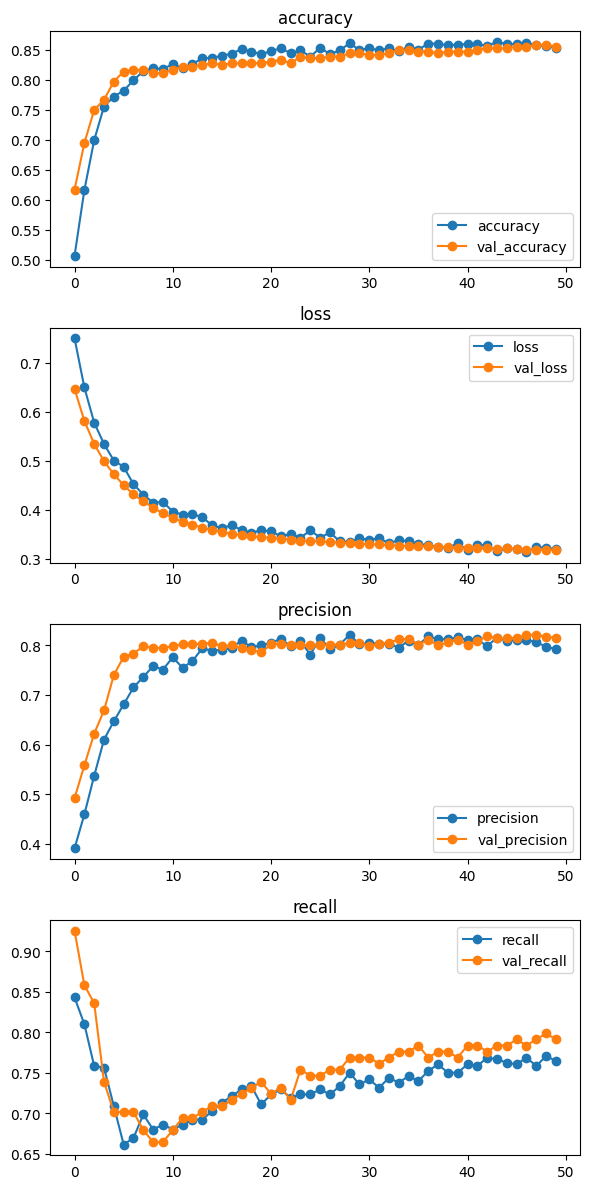

In [121]:
# plot learning history
plot_history(history);

In [122]:
# make predictions
y_pred_test = clf_model.predict(X_test_scaled)
y_pred_test[:5]

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[0.19384263],
       [0.8063616 ],
       [0.21929125],
       [0.2508669 ],
       [0.9974619 ]], dtype=float32)

In [123]:
# round the predictions
y_pred_test = np.round(y_pred_test)
y_pred_test[:5]

array([[0.],
       [1.],
       [0.],
       [0.],
       [1.]], dtype=float32)

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       397
           1       0.79      0.72      0.75       204

    accuracy                           0.84       601
   macro avg       0.83      0.81      0.82       601
weighted avg       0.84      0.84      0.84       601



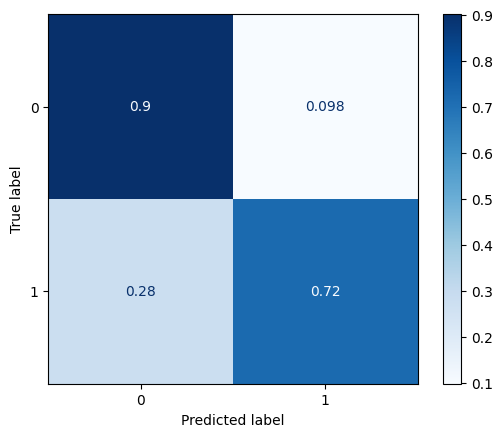

In [124]:
#Confusion Matrix and Classification Report
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues',
                                       normalize='true');

## Hyperparameter Tuning
Keras Tuner is used to search for a better neural network configuration.

In [125]:
# Install and import Keras Tuner for hyperparameter optimization
!pip install -q keras-tuner

import keras_tuner as kt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import metrics

### Define Tunable Model
The tuner will search for the best number of units, dropout rate, and optimizer.

In [127]:

def build_model(hp):

    model = Sequential()

    model.add(Dense(units=hp.Int('units', min_value=10, max_value=50, step=5), activation='relu'))
    model.add(Dropout(hp.Float(name="dropout_value", min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation = 'sigmoid'))
    model.compile(optimizer=hp.Choice('optimizer',['rmsprop','nadam','adam']),
                  loss='bce',
                  metrics=['accuracy',
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.Precision(name='precision')])
    return model

# Define the folder where tuner results will be saved


In [128]:
# Make a folder to store results of hyperparameter tuning
import os
folder = 'KerasTuner/'
os.makedirs(folder, exist_ok=True)


In [129]:
# Define tuner object
tuner = kt.RandomSearch(build_model,
                     objective='val_accuracy',
                     directory=folder,
                     overwrite = True,
                     seed = 42,
                     project_name='Rookie_tuning')

In [130]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=5,restore_best_weights=True)

### Run Hyperparameter Search
The tuner evaluates multiple configurations and selects the model with the best validation accuracy.

In [131]:
# Run the tuner
tuner.search(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop]
)

Trial 10 Complete [00h 00m 08s]
val_accuracy: 0.8416666388511658

Best val_accuracy So Far: 0.8583333492279053
Total elapsed time: 00h 01m 22s


In [132]:
# Obtain best hyperparameter values
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values


{'units': 30, 'dropout_value': 0.0, 'optimizer': 'nadam'}

In [133]:
# Obtain best model
best_model = tuner.get_best_models()[0]
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 11 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 30)               │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 30)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 451 (1.76 KB)

 Trainable params: 451 (1.76 KB)

 Non-trainable params: 0 (0.00 B)

### Evaluate Tuned Model
The tuned neural network is evaluated on the unseen test set.

In [134]:
# Evaluate neural network with built in evaluation
result = best_model.evaluate(X_test_scaled, y_test, return_dict=True)
result


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8393 - loss: 0.3441 - precision: 0.7856 - recall: 0.6814


{'accuracy': 0.8336106538772583,
 'loss': 0.36835870146751404,
 'precision': 0.7888888716697693,
 'recall': 0.6960784196853638}

In [135]:
# Inspect results in more detail
tuner.results_summary(5)

Results summary
Results in KerasTuner/Rookie_tuning
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 02 summary
Hyperparameters:
units: 30
dropout_value: 0.0
optimizer: nadam
Score: 0.8583333492279053

Trial 03 summary
Hyperparameters:
units: 50
dropout_value: 0.0
optimizer: adam
Score: 0.8527777791023254

Trial 04 summary
Hyperparameters:
units: 10
dropout_value: 0.2
optimizer: rmsprop
Score: 0.8527777791023254

Trial 06 summary
Hyperparameters:
units: 30
dropout_value: 0.2
optimizer: nadam
Score: 0.8527777791023254

Trial 05 summary
Hyperparameters:
units: 20
dropout_value: 0.2
optimizer: adam
Score: 0.8500000238418579


In [136]:
y_pred_best = best_model.predict(X_test_scaled)
y_pred_best = (y_pred_best > 0.5).astype(int).ravel()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


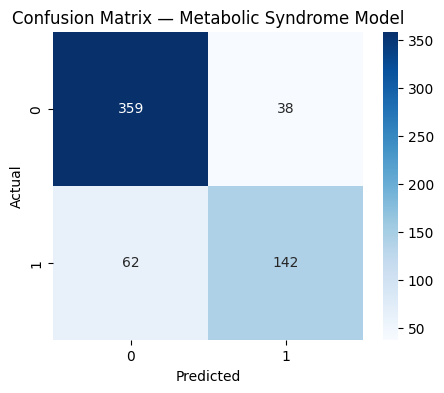

In [137]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Metabolic Syndrome Model")

plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       397
           1       0.79      0.70      0.74       204

    accuracy                           0.83       601
   macro avg       0.82      0.80      0.81       601
weighted avg       0.83      0.83      0.83       601



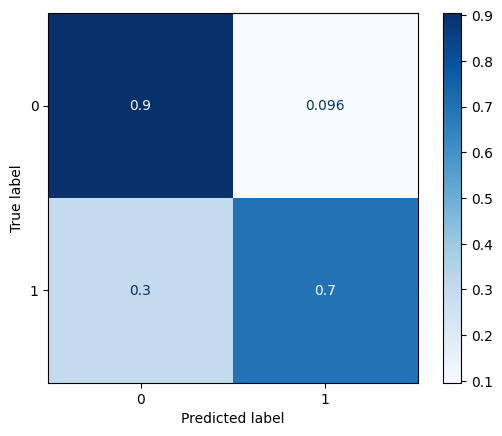

In [138]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test_scaled)
y_pred_best = (y_pred_best > 0.5).astype(int).ravel()

print(classification_report(y_test, y_pred_best))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap='Blues',
    normalize='true'
)

## Conclusion
The tuned neural network achieved approximately 83% accuracy on the test dataset.

The model correctly classified most healthy individuals and detected a meaningful proportion of metabolic syndrome cases. Hyperparameter tuning provided a small improvement over the baseline neural network.

Overall, the neural network demonstrates useful predictive ability for metabolic syndrome classification using clinical features.